# Master Dataset Generation

This notebook reads all CSV files from the `Data-Extraction` folder, surveys column headings,
maps similar/related column names to canonical keys using `refined_header_mapping.json`,
builds a unified master dataset, applies linear interpolation to columns present in ≥ 21 files,
and appends a `MONTH_YEAR` column (MM/YY) derived from each filename.

---
**First-time setup (from the `Analysis/` directory):**
```bash
python -m venv venv
source venv/bin/activate        # Windows: venv\Scripts\activate
pip install -r requirements.txt
jupyter lab                     # then open master_dataset.ipynb
```


## Section 0 — Imports & Configuration

In [1]:
import os
import json
import re
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ──────────────────────────────────────────────────
# PATHS  (relative to the Analysis/ folder)
# ──────────────────────────────────────────────────
ANALYSIS_DIR   = Path(os.getcwd())                        # …/Analysis/
DATA_DIR       = ANALYSIS_DIR.parent / 'Data-Extraction'  # …/Data-Extraction/
MAPPING_FILE   = ANALYSIS_DIR.parent / 'Code' / 'refined_header_mapping.json'
OUTPUT_CSV     = ANALYSIS_DIR / 'master_dataset.csv'

FREQ_THRESHOLD = 21   # keep & interpolate columns present in >= this many files

# Categorical / text columns — fill by propagation, not numeric interpolation
LABEL_COLS = {'STN_CODE', 'NAMEOFMONITORINGLOCATION', 'USEBASEDCLASS',
              'SAMPLINGMONTH', 'YEAR'}

print(f"Data directory : {DATA_DIR}")
print(f"Mapping file   : {MAPPING_FILE}")
print(f"Output CSV     : {OUTPUT_CSV}")


Data directory : /Users/knight_striker/Desktop/Correlation-Expression-Prediction/Data-Extraction
Mapping file   : /Users/knight_striker/Desktop/Correlation-Expression-Prediction/Code/refined_header_mapping.json
Output CSV     : /Users/knight_striker/Desktop/Correlation-Expression-Prediction/Analysis/master_dataset.csv


---
## Section 1 — Column Survey

Read only the header row from every CSV and build a frequency table that shows how many files contain each column.


In [2]:
csv_files = sorted(DATA_DIR.glob('*.csv'))
print(f"Found {len(csv_files)} CSV files in {DATA_DIR}\n")

col_freq     = Counter()   # column_name -> count of files
file_headers = {}          # filename    -> list of raw headers

for fpath in csv_files:
    df_hdr = pd.read_csv(fpath, nrows=0)
    raw_cols = [c.strip() for c in df_hdr.columns
                if 'Unnamed' not in c and c.strip()]
    file_headers[fpath.name] = raw_cols
    col_freq.update(raw_cols)

survey_df = pd.DataFrame(col_freq.most_common(),
                         columns=['Column Name', 'Files Present'])
survey_df['Passes Threshold (>=21)'] = survey_df['Files Present'] >= FREQ_THRESHOLD

print(f"Total unique column names found : {len(survey_df)}")
print(f"Columns passing threshold (>={FREQ_THRESHOLD}): {survey_df['Passes Threshold (>=21)'].sum()}")
print()

# Colour the boolean column — compatible with pandas 1.x and 2.x
def _style_bool(v):
    if v is True:
        return 'background-color: #d4edda'
    if v is False:
        return 'background-color: #f8d7da'
    return ''

styler = survey_df.style
# pandas >= 2.0 renamed applymap -> map
if hasattr(styler, 'map'):
    display(styler.map(_style_bool, subset=['Passes Threshold (>=21)']))
else:
    display(styler.applymap(_style_bool, subset=['Passes Threshold (>=21)']))


Found 25 CSV files in /Users/knight_striker/Desktop/Correlation-Expression-Prediction/Data-Extraction

Total unique column names found : 33
Columns passing threshold (>=21): 33



,Column Name,Files Present,Passes Threshold (>=21)
0,STN_CODE,25,True
1,NAMEOFMONITORINGLOCATION,25,True
2,USEBASEDCLASS,25,True
3,DO,25,True
4,PH,25,True
5,CONDUCTIVITY,25,True
6,BOD,25,True
7,NITRATE_N,25,True
8,FECAL_COLI,25,True
9,TOTAL_COLI,25,True


### 1.1 — Column frequency bar chart

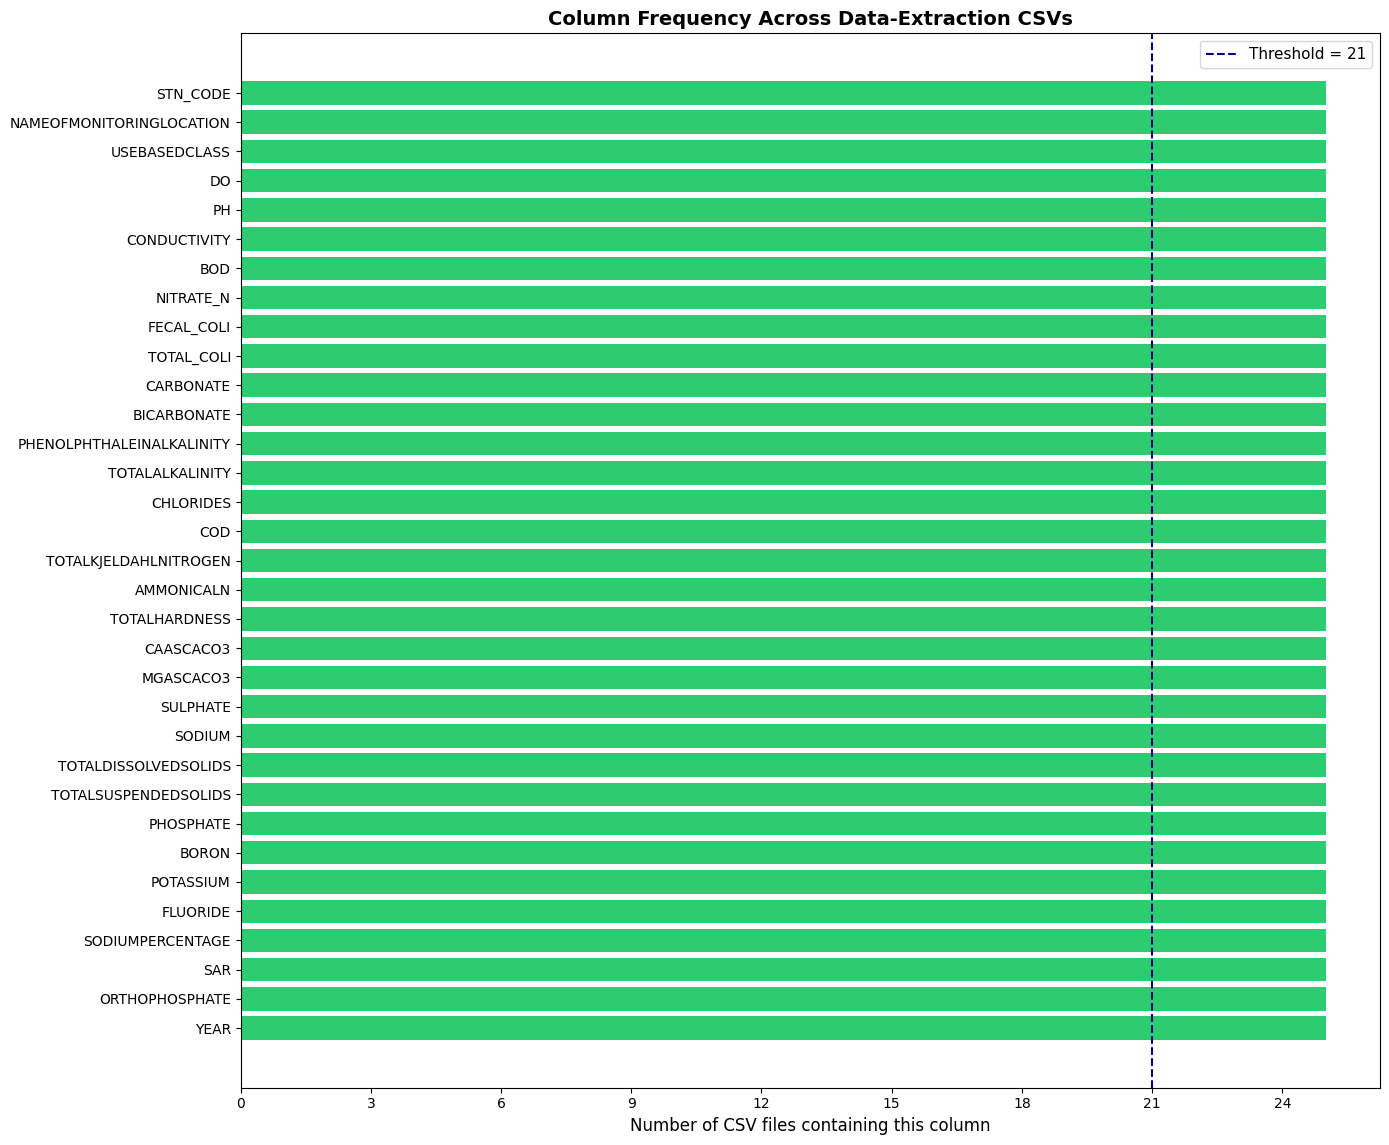

In [3]:
fig, ax = plt.subplots(figsize=(14, max(6, len(survey_df) * 0.35)))

colors = ['#2ecc71' if v else '#e74c3c'
          for v in survey_df['Passes Threshold (>=21)']]

ax.barh(survey_df['Column Name'], survey_df['Files Present'], color=colors)
ax.axvline(FREQ_THRESHOLD, color='navy', linestyle='--', linewidth=1.5,
           label=f'Threshold = {FREQ_THRESHOLD}')
ax.set_xlabel('Number of CSV files containing this column', fontsize=12)
ax.set_title('Column Frequency Across Data-Extraction CSVs',
             fontsize=14, fontweight='bold')
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.legend(fontsize=11)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(ANALYSIS_DIR / 'column_frequency.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Section 2 — Load Column Mapping & Build Raw Master Dataset

`refined_header_mapping.json` (in the `Code/` folder) maps every raw column-name variant to a single canonical key. We apply this mapping on load so all files share one unified schema.


In [4]:
with open(MAPPING_FILE, 'r') as fh:
    header_mapping = json.load(fh)

# Build reverse lookup:  raw_variant -> canonical_key
rename_lookup = {
    variant.strip(): canonical
    for canonical, variants in header_mapping.items()
    for variant in variants
}

print(f"Mapping loaded : {len(header_mapping)} canonical keys")
print(f"Reverse lookup : {len(rename_lookup)} raw-name variants")


Mapping loaded : 56 canonical keys
Reverse lookup : 114 raw-name variants


In [5]:
def parse_month_year(filename_stem: str) -> str:
    """
    'July-23' -> '07/23'  |  'April-25' -> '04/25'
    Handles both 2-digit and 4-digit year suffixes.
    """
    month_map = {
        'january': '01', 'february': '02', 'march': '03', 'april': '04',
        'may': '05',     'june': '06',     'july': '07',  'august': '08',
        'september': '09', 'october': '10', 'november': '11', 'december': '12',
    }
    parts = filename_stem.lower().split('-')
    if len(parts) < 2:
        return 'UNKNOWN'
    month_num = month_map.get(parts[0].strip(), '00')
    year_2d   = parts[1].strip()[-2:]   # '2023' -> '23' | '23' -> '23'
    return f"{month_num}/{year_2d}"


# Quick sanity test
for test in ['July-23', 'April-25', 'November-25', 'September-23']:
    print(f"  {test}  ->  {parse_month_year(test)}")


  July-23  ->  07/23
  April-25  ->  04/25
  November-25  ->  11/25
  September-23  ->  09/23


In [6]:
def _sort_key(fpath: Path):
    """Return (year, month_idx) for chronological ordering."""
    month_order = {
        'january': 1, 'february': 2, 'march': 3, 'april': 4,
        'may': 5,     'june': 6,     'july': 7,  'august': 8,
        'september': 9, 'october': 10, 'november': 11, 'december': 12,
    }
    parts = fpath.stem.lower().split('-')
    month = month_order.get(parts[0], 0)
    year  = int(parts[1]) if len(parts) > 1 else 0
    if year < 100:
        year += 2000
    return (year, month)


csv_files_sorted = sorted(csv_files, key=_sort_key)

print("Files in chronological order:")
for f in csv_files_sorted:
    print(f"  {f.name:<25}  MONTH_YEAR = {parse_month_year(f.stem)}")


Files in chronological order:
  July-23.csv                MONTH_YEAR = 07/23
  August-23.csv              MONTH_YEAR = 08/23
  September-23.csv           MONTH_YEAR = 09/23
  October-23.csv             MONTH_YEAR = 10/23
  December-23.csv            MONTH_YEAR = 12/23
  March-24.csv               MONTH_YEAR = 03/24
  April-24.csv               MONTH_YEAR = 04/24
  May-24.csv                 MONTH_YEAR = 05/24
  June-24.csv                MONTH_YEAR = 06/24
  July-24.csv                MONTH_YEAR = 07/24
  August-24.csv              MONTH_YEAR = 08/24
  September-24.csv           MONTH_YEAR = 09/24
  October-24.csv             MONTH_YEAR = 10/24
  December-24.csv            MONTH_YEAR = 12/24
  January-25.csv             MONTH_YEAR = 01/25
  February-25.csv            MONTH_YEAR = 02/25
  March-25.csv               MONTH_YEAR = 03/25
  April-25.csv               MONTH_YEAR = 04/25
  May-25.csv                 MONTH_YEAR = 05/25
  June-25.csv                MONTH_YEAR = 06/25
  July-25.

In [7]:
all_dfs = []

for fpath in csv_files_sorted:
    df = pd.read_csv(fpath)

    # Strip whitespace from column names
    df.columns = [c.strip() for c in df.columns]

    # Map any residual raw-variant column names to canonical keys
    df = df.rename(columns=rename_lookup)

    # Drop ghost 'Unnamed' columns
    df = df.loc[:, ~df.columns.str.contains('^Unnamed', na=False)]

    # Prepend the MONTH_YEAR tag
    df.insert(0, 'MONTH_YEAR', parse_month_year(fpath.stem))

    all_dfs.append(df)

raw_master = pd.concat(all_dfs, axis=0, ignore_index=True, sort=False)
print(f"Raw master shape : {raw_master.shape}")
print(f"Columns          : {list(raw_master.columns)}")


Raw master shape : (2924, 34)
Columns          : ['MONTH_YEAR', 'STN_CODE', 'NAMEOFMONITORINGLOCATION', 'USEBASEDCLASS', 'DO', 'PH', 'CONDUCTIVITY', 'BOD', 'NITRATE_N', 'FECAL_COLI', 'TOTAL_COLI', 'CARBONATE', 'BICARBONATE', 'PHENOLPHTHALEINALKALINITY', 'TOTALALKALINITY', 'CHLORIDES', 'COD', 'TOTALKJELDAHLNITROGEN', 'AMMONICALN', 'TOTALHARDNESS', 'CAASCACO3', 'MGASCACO3', 'SULPHATE', 'SODIUM', 'TOTALDISSOLVEDSOLIDS', 'TOTALSUSPENDEDSOLIDS', 'PHOSPHATE', 'BORON', 'POTASSIUM', 'FLUORIDE', 'SODIUMPERCENTAGE', 'SAR', 'ORTHOPHOSPHATE', 'YEAR']


---
## Section 3 — Filter Columns: Keep Those Present in >= 21 Files

Count, per canonical column name, how many source files contain it. Only columns with count >= 21 are retained in the master dataset.


In [8]:
# Count using the canonically-mapped names
mapped_col_freq = Counter()
for fpath in csv_files_sorted:
    df_hdr   = pd.read_csv(fpath, nrows=0)
    can_cols = [
        rename_lookup.get(c.strip(), c.strip())
        for c in df_hdr.columns
        if 'Unnamed' not in c and c.strip()
    ]
    mapped_col_freq.update(set(can_cols))  # set: count each file once per column

passing_cols = {col for col, cnt in mapped_col_freq.items() if cnt >= FREQ_THRESHOLD}

# MONTH_YEAR is always kept (we derived it, it's not in source files)
keep_cols = ['MONTH_YEAR'] + [
    col for col in raw_master.columns
    if col != 'MONTH_YEAR' and col in passing_cols
]
dropped_cols = [c for c in raw_master.columns if c not in keep_cols]

print(f"Columns passing threshold (>={FREQ_THRESHOLD} files): {len(keep_cols) - 1}")
print(f"Columns dropped                                    : {len(dropped_cols)}")
if dropped_cols:
    print(f"  Dropped: {dropped_cols}")

master_df = raw_master[keep_cols].copy()
print(f"\nMaster dataset shape after filtering: {master_df.shape}")


Columns passing threshold (>=21 files): 33
Columns dropped                                    : 0

Master dataset shape after filtering: (2924, 34)


---
## Section 4 — Interpolation

| Column type | Strategy |
|---|---|
| Numeric water-quality parameters | **Linear interpolation** per monitoring station (`STN_CODE` group), then `limit_direction='both'` to fill any leading/trailing NaNs |
| Categorical / identifier columns | Forward-fill then back-fill |

> **Why linear interpolation?**  
> These are monthly measurements at fixed stations — a temporal sequence. Linear interpolation respects chronological order, requires no distributional assumptions, and avoids the artificial oscillations that polynomial or spline methods can cause on sparse data.


In [9]:
label_cols_present = [c for c in LABEL_COLS if c in master_df.columns]
non_interp_cols    = {'MONTH_YEAR'} | LABEL_COLS
numeric_cols       = [c for c in master_df.columns if c not in non_interp_cols]

print(f"Label / categorical columns     : {label_cols_present}")
print(f"Numeric columns to interpolate  : {len(numeric_cols)}")
print(f"  {numeric_cols}")


Label / categorical columns     : ['NAMEOFMONITORINGLOCATION', 'YEAR', 'USEBASEDCLASS', 'STN_CODE']
Numeric columns to interpolate  : 29
  ['DO', 'PH', 'CONDUCTIVITY', 'BOD', 'NITRATE_N', 'FECAL_COLI', 'TOTAL_COLI', 'CARBONATE', 'BICARBONATE', 'PHENOLPHTHALEINALKALINITY', 'TOTALALKALINITY', 'CHLORIDES', 'COD', 'TOTALKJELDAHLNITROGEN', 'AMMONICALN', 'TOTALHARDNESS', 'CAASCACO3', 'MGASCACO3', 'SULPHATE', 'SODIUM', 'TOTALDISSOLVEDSOLIDS', 'TOTALSUSPENDEDSOLIDS', 'PHOSPHATE', 'BORON', 'POTASSIUM', 'FLUORIDE', 'SODIUMPERCENTAGE', 'SAR', 'ORTHOPHOSPHATE']


In [10]:
# Step A — coerce to float (strips 'BDL', '<0.1', trailing units, etc.)
for col in numeric_cols:
    master_df[col] = (
        master_df[col]
        .astype(str)
        .str.extract(r'([+\-]?\d*\.?\d+)', expand=False)
        .astype(float)
    )

null_before = master_df[numeric_cols].isnull().sum().sum()
print(f"NaN count in numeric cols BEFORE interpolation: {null_before}")


NaN count in numeric cols BEFORE interpolation: 0


In [11]:
# Step B — linear interpolation, grouped by monitoring station
if 'STN_CODE' in master_df.columns:
    master_df[numeric_cols] = (
        master_df
        .groupby('STN_CODE', group_keys=False)[numeric_cols]
        .apply(lambda g: g.interpolate(method='linear', limit_direction='both'))
    )
else:
    # Fallback: global linear interpolation
    master_df[numeric_cols] = master_df[numeric_cols].interpolate(
        method='linear', limit_direction='both'
    )

null_after_interp = master_df[numeric_cols].isnull().sum().sum()
print(f"NaN count in numeric cols AFTER interpolation : {null_after_interp}")


NaN count in numeric cols AFTER interpolation : 0


In [12]:
# Step C — fill any residual NaNs (e.g. column entirely missing for one station)
for col in numeric_cols:
    if master_df[col].isnull().any():
        col_median = master_df[col].median()
        master_df[col] = master_df[col].fillna(col_median)
        print(f"  Residual fill '{col}' with median = {col_median:.4f}")

# Step D — fill categorical / label columns
for col in label_cols_present:
    master_df[col] = master_df[col].ffill().bfill()

final_nulls = master_df.isnull().sum().sum()
print(f"\nTotal NaN remaining in master dataset: {final_nulls}")



Total NaN remaining in master dataset: 0


---
## Section 5 — Save Master Dataset


In [13]:
master_df.to_csv(OUTPUT_CSV, index=False)
print(f"Master dataset saved to : {OUTPUT_CSV}")
print(f"Shape                   : {master_df.shape}  "
      f"({master_df.shape[0]} rows x {master_df.shape[1]} columns)")


Master dataset saved to : /Users/knight_striker/Desktop/Correlation-Expression-Prediction/Analysis/master_dataset.csv
Shape                   : (2924, 34)  (2924 rows x 34 columns)


---
## Section 6 — Sanity Checks & Quick Exploration


In [14]:
# ── Assertions
assert master_df['MONTH_YEAR'].notna().all(), 'MONTH_YEAR has missing values!'
assert master_df.isnull().sum().sum() == 0,   'There are remaining NaN values!'
assert master_df.shape[1] >= 33,              'Expected at least 33 columns!'
print('All sanity checks passed.')


All sanity checks passed.


In [15]:
# ── Preview
print('First 5 rows:')
display(master_df.head())

print('\nColumn dtypes:')
display(master_df.dtypes.to_frame('dtype'))

print('\nDescriptive statistics (numeric columns):')
display(master_df[numeric_cols].describe().T.style.format('{:.4f}'))


First 5 rows:


,MONTH_YEAR,STN_CODE,NAMEOFMONITORINGLOCATION,USEBASEDCLASS,DO,PH,CONDUCTIVITY,BOD,NITRATE_N,FECAL_COLI,...,TOTALDISSOLVEDSOLIDS,TOTALSUSPENDEDSOLIDS,PHOSPHATE,BORON,POTASSIUM,FLUORIDE,SODIUMPERCENTAGE,SAR,ORTHOPHOSPHATE,YEAR
0,07/23,5574.0,DEVASANDRA LAKE,"D (Propagation of wild life,fisheries)",4.4,8.2,392.0,7.0,1.0,6300.0,...,268.0,12.175824,0.56,0.5,13.0,0.23,43.956044,1.794505,0.297253,2023.0
1,07/23,5574.0,HEBBAL LAKE,"D (Propagation of wild life,fisheries)",4.7,7.2,550.0,8.0,2.0,2300.0,...,376.0,12.351648,0.98,0.5,27.0,0.28,43.912088,1.789011,0.294505,2023.0
2,07/23,5574.0,JAKKUR LAKE,"E (Irrigation, industrial cooling and controll...",2.6,7.0,908.0,12.0,4.1,4000.0,...,620.0,12.527473,2.40,0.5,32.0,0.45,43.868132,1.783516,0.291758,2023.0
3,07/23,5574.0,NAGAVARA LAKE,"D (Propagation of wild life,fisheries)",4.9,7.0,550.0,8.0,2.0,1300.0,...,372.0,12.703297,0.70,0.5,26.0,0.32,43.824176,1.778022,0.289011,2023.0
4,07/23,5574.0,CHELEKERE LAKE,"D (Propagation of wild life,fisheries)",4.8,7.1,548.0,8.0,0.3,1700.0,...,372.0,12.879121,0.83,0.5,26.0,0.30,43.780220,1.772527,0.286264,2023.0



Column dtypes:


,dtype
MONTH_YEAR,str
STN_CODE,float64
NAMEOFMONITORINGLOCATION,object
USEBASEDCLASS,object
DO,float64
PH,float64
CONDUCTIVITY,float64
BOD,float64
NITRATE_N,float64
FECAL_COLI,float64



Descriptive statistics (numeric columns):


,count,mean,std,min,25%,50%,75%,max
DO,2924.0000,4.0895,1.9567,0.0200,2.8000,4.6000,5.7000,8.0000
PH,2924.0000,816.2867,26549.3832,1.9000,7.0000,7.4000,7.9000,1100000.0000
CONDUCTIVITY,2924.0000,4817.3191,124584.7149,63.0000,512.0000,740.0000,1140.0000,4900000.0000
BOD,2924.0000,14.8165,20.2188,3.2000,5.0000,8.0000,17.0000,450.0000
NITRATE_N,2924.0000,3.3792,2.9009,0.3000,1.8700,2.8000,4.0000,49.0000
FECAL_COLI,2924.0000,445589.7765,20382147.7649,2.0000,230.0000,630.0000,2600.0000,1100000000.0000
TOTAL_COLI,2924.0000,1579364.6546,61710967.8020,1.5000,2400.0000,5400.0000,16000.0000,3300000000.0000
CARBONATE,2924.0000,18.9925,42.6254,3.0000,3.0000,3.0000,18.8629,436.0000
BICARBONATE,2924.0000,194.0414,140.7183,8.0000,112.0000,156.0000,240.0000,2590.0000
PHENOLPHTHALEINALKALINITY,2924.0000,9.5746,13.6537,1.5000,5.0000,5.0000,12.0000,200.0000


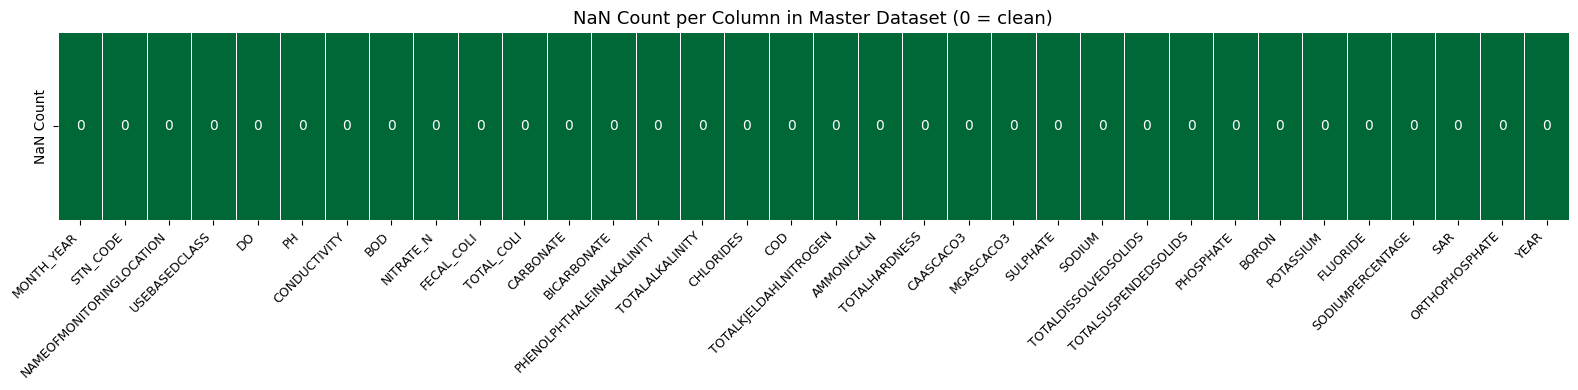

In [16]:
# ── Null heatmap (should be all zeros)
fig, ax = plt.subplots(figsize=(16, 4))
null_counts = master_df.isnull().sum().to_frame('NaN Count').T
sns.heatmap(null_counts, annot=True, fmt='d', cmap='RdYlGn_r',
            linewidths=0.5, ax=ax, cbar=False)
ax.set_title('NaN Count per Column in Master Dataset (0 = clean)', fontsize=13)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
plt.tight_layout()
plt.savefig(ANALYSIS_DIR / 'null_check.png', dpi=150, bbox_inches='tight')
plt.show()


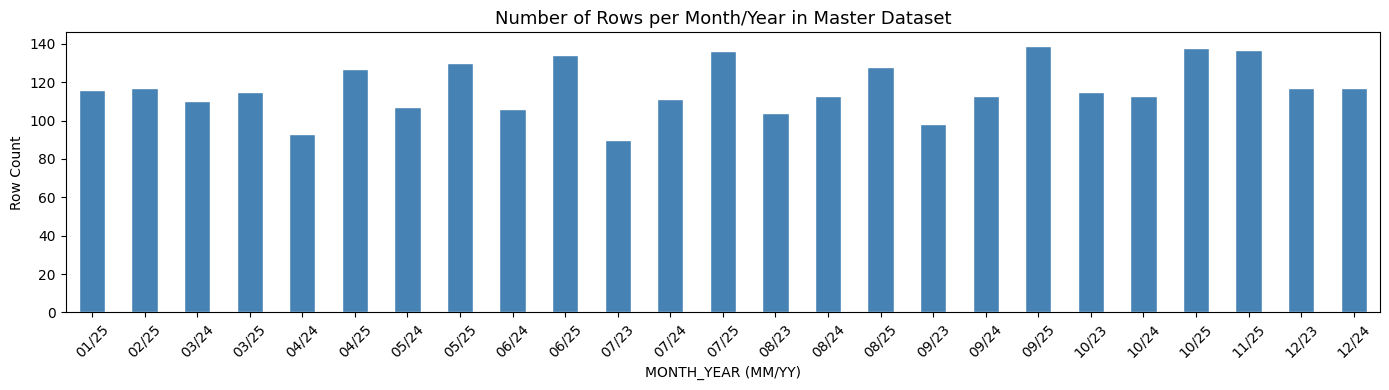

MONTH_YEAR
01/25    116
02/25    117
03/24    110
03/25    115
04/24     93
04/25    127
05/24    107
05/25    130
06/24    106
06/25    134
07/23     90
07/24    111
07/25    136
08/23    104
08/24    113
08/25    128
09/23     98
09/24    113
09/25    139
10/23    115
10/24    113
10/25    138
11/25    137
12/23    117
12/24    117
Name: count, dtype: int64


In [17]:
# ── Rows per MONTH_YEAR
monthly_counts = master_df['MONTH_YEAR'].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(14, 4))
monthly_counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Number of Rows per Month/Year in Master Dataset', fontsize=13)
ax.set_xlabel('MONTH_YEAR (MM/YY)')
ax.set_ylabel('Row Count')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(ANALYSIS_DIR / 'rows_per_month.png', dpi=150, bbox_inches='tight')
plt.show()
print(monthly_counts)


---
## Summary

| Item | Value |
|---|---|
| Source files processed | 25 |
| Frequency threshold | >= 21 files |
| Interpolation method | Linear, per monitoring station |
| Date tag column | `MONTH_YEAR` (MM/YY, from filename) |
| Output file | `Analysis/master_dataset.csv` |

The master dataset is ready for downstream correlation analysis and predictive modelling.
